# Palmer Penguins Classification Model

Dataset: Palmer Archipelago (Antarctica) Penguin Data
Goal: Predict penguin species (Adelie / Chinstrap / Gentoo)
Models: Decision Tree, K-Nearest Neighbors, Random Forest

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

## 1. Load The Data

In [2]:


df = sns.load_dataset("penguins")
print("penguins_size.csv not found. Loaded seaborn built-in penguins dataset instead.")
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Shape      : {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Columns    : {df.columns.tolist()}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nClass distribution:\n{df['species'].value_counts()}")
print(f"\nMissing values:\n{df.isnull().sum()}")

penguins_size.csv not found. Loaded seaborn built-in penguins dataset instead.
DATASET OVERVIEW
Shape      : 344 rows x 7 columns
Columns    : ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']

First 5 rows:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  

Class distribution:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

Missing values:
species               0


## 2. Data Cleaning

In [3]:
print("\n" + "=" * 50)
print("DATA CLEANING")
print("=" * 50)


df = df.dropna()
print(f"Rows after dropping NaN : {len(df)}")


features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
target = "species"

X = df[features]
y = df[target]


le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Species label mapping : {dict(zip(le.classes_, le.transform(le.classes_)))}")


DATA CLEANING
Rows after dropping NaN : 333
Species label mapping : {'Adelie': np.int64(0), 'Chinstrap': np.int64(1), 'Gentoo': np.int64(2)}


## 3. Exploratory Data Analysis


EXPLORATORY DATA ANALYSIS
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count          333.00         333.00             333.00       333.00
mean            43.99          17.16             200.97      4207.06
std              5.47           1.97              14.02       805.22
min             32.10          13.10             172.00      2700.00
25%             39.50          15.60             190.00      3550.00
50%             44.50          17.30             197.00      4050.00
75%             48.60          18.70             213.00      4775.00
max             59.60          21.50             231.00      6300.00


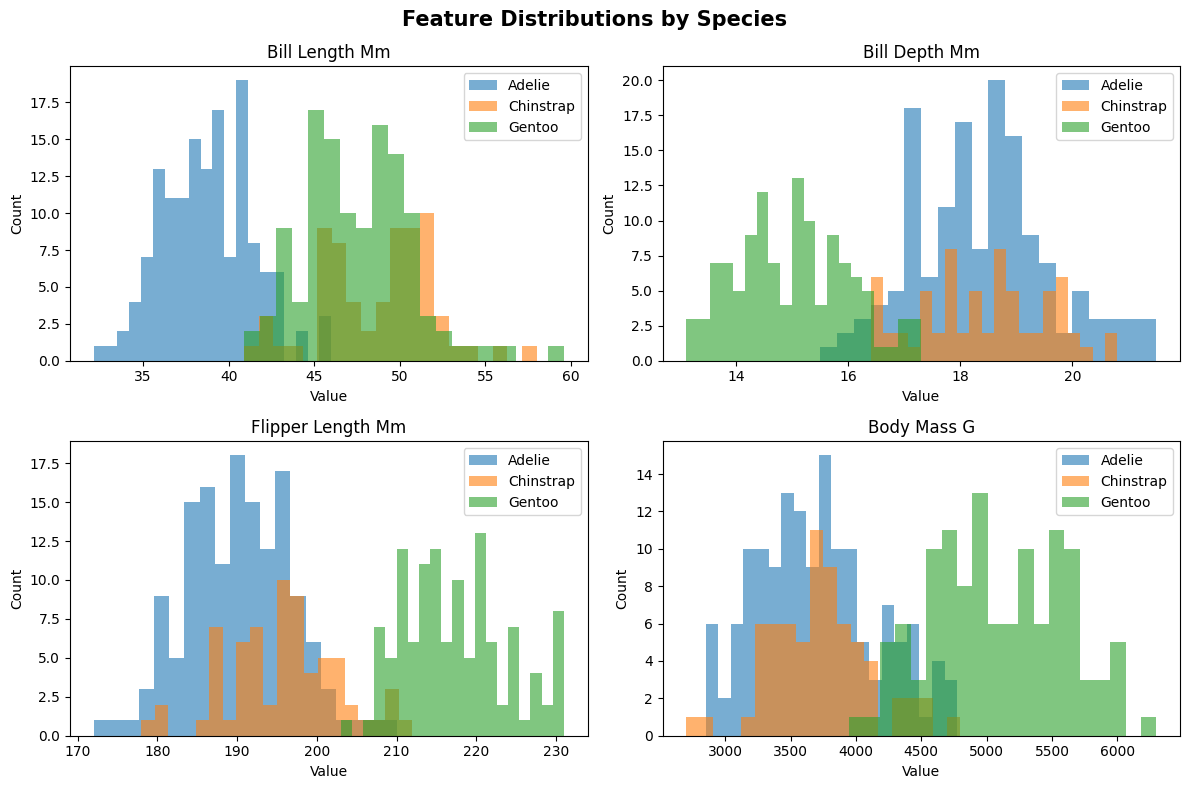

Saved: 1_feature_distributions.png


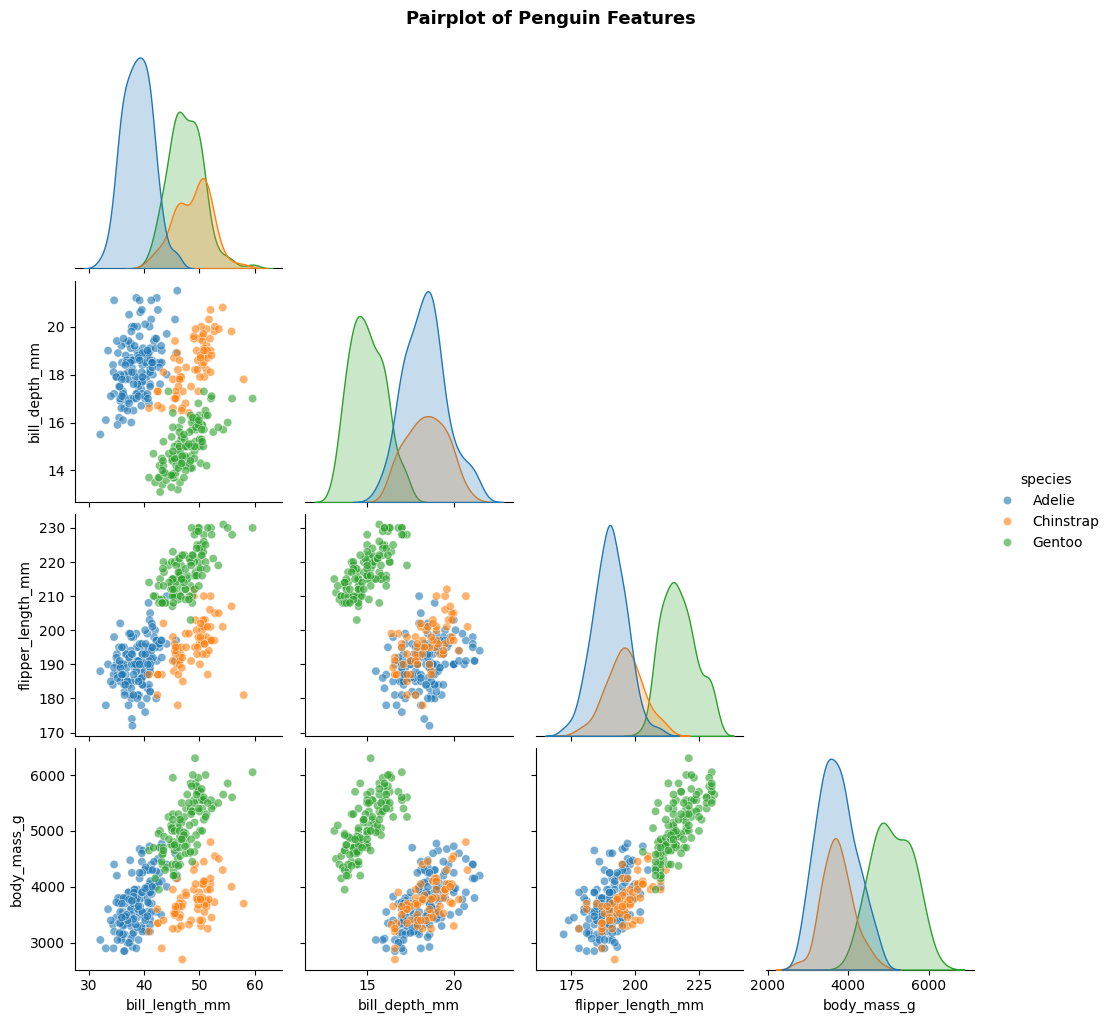

Saved: 2_pairplot.png


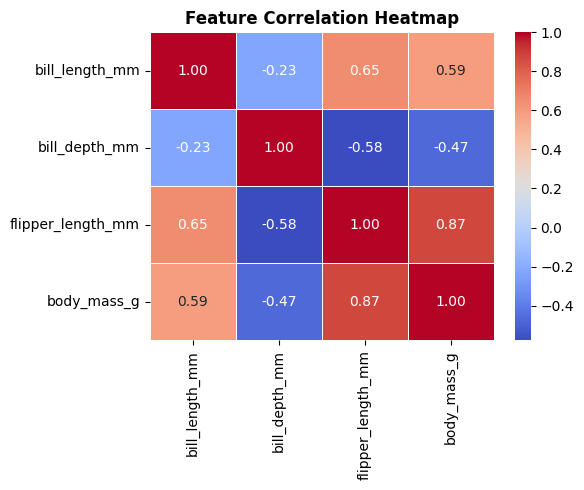

Saved: 3_correlation_heatmap.png


In [ ]:
print("\n" + "=" * 50)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 50)
print(df[features].describe().round(2))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Feature Distributions by Species", fontsize=15, fontweight="bold")

for ax, feature in zip(axes.flatten(), features):
    for species in df["species"].unique():
        subset = df[df["species"] == species][feature]
        ax.hist(subset, bins=20, alpha=0.6, label=species)
    ax.set_title(feature.replace("_", " ").title())
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.savefig("1_feature_distributions.png", dpi=120)
plt.show()
plt.close()
print("Saved: 1_feature_distributions.png")

pair_data = df[features + ["species"]]
sns.pairplot(pair_data, hue="species", corner=True, plot_kws={"alpha": 0.6})
plt.suptitle("Pairplot of Penguin Features", y=1.02, fontsize=13, fontweight="bold")
plt.savefig("2_pairplot.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close()
print("Saved: 2_pairplot.png")

plt.figure(figsize=(6, 5))
corr_data = df[features].copy()
corr_data["species_encoded"] = y_encoded
corr = corr_data.corr().rename(
    index={"species_encoded": "species"},
    columns={"species_encoded": "species"},
)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap (Including Species)", fontweight="bold")
plt.tight_layout()
plt.savefig("3_correlation_heatmap.png", dpi=120)
plt.show()
plt.close()
print("Saved: 3_correlation_heatmap.png")

## 4. Train/Test Split and Scaling

In [5]:
print("\n" + "=" * 50)
print("TRAIN / TEST SPLIT (80% train, 20% test)")
print("=" * 50)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


TRAIN / TEST SPLIT (80% train, 20% test)
Training samples : 266
Testing samples  : 67


## 5. Train and Evaluate Models

In [6]:
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "K-Nearest Neighbors (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}

print("\n" + "=" * 50)
print("MODEL RESULTS")
print("=" * 50)

for name, model in models.items():
    if "Nearest" in name or "Forest" in name:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = {"model": model, "y_pred": y_pred, "accuracy": acc}

    print(f"\n{'-' * 40}")
    print(f"  {name}")
    print(f"{'-' * 40}")
    print(f"  Accuracy : {acc:.2%}")
    print("\n  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))


MODEL RESULTS

----------------------------------------
  Decision Tree
----------------------------------------
  Accuracy : 94.03%

  Classification Report:
              precision    recall  f1-score   support

      Adelie       0.96      0.93      0.95        29
   Chinstrap       0.82      1.00      0.90        14
      Gentoo       1.00      0.92      0.96        24

    accuracy                           0.94        67
   macro avg       0.93      0.95      0.94        67
weighted avg       0.95      0.94      0.94        67


----------------------------------------
  K-Nearest Neighbors (k=5)
----------------------------------------
  Accuracy : 100.00%

  Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      

## 6. Confusion Matrices

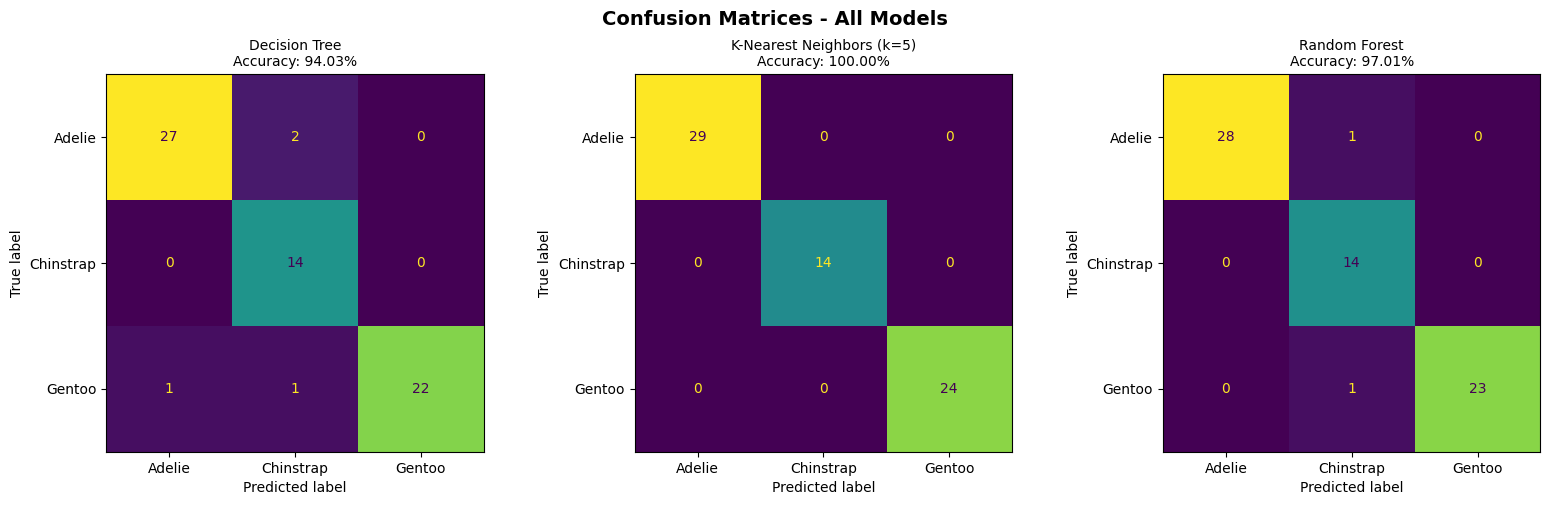

Saved: 4_confusion_matrices.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Confusion Matrices - All Models", fontsize=14, fontweight="bold")

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"{name}\nAccuracy: {res['accuracy']:.2%}", fontsize=10)

plt.tight_layout()
plt.savefig("4_confusion_matrices.png", dpi=120)
plt.show()
plt.close()
print("Saved: 4_confusion_matrices.png")

## 7. Model Comparison

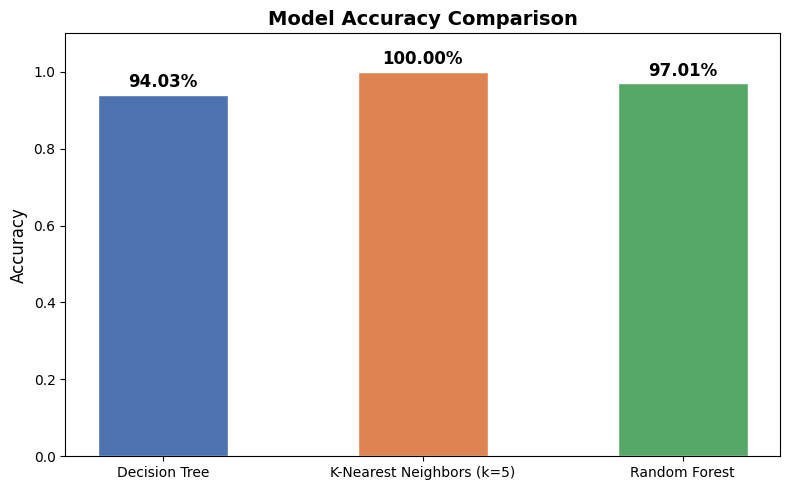

Saved: 5_model_comparison.png


In [8]:
names = list(results.keys())
accs = [r["accuracy"] for r in results.values()]
colors = ["#4C72B0", "#DD8452", "#55A868"]

plt.figure(figsize=(8, 5))
bars = plt.bar(names, accs, color=colors, edgecolor="white", width=0.5)
plt.ylim(0, 1.1)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Model Accuracy Comparison", fontsize=14, fontweight="bold")
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.02,
             f"{acc:.2%}", ha="center", fontsize=12, fontweight="bold")
plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig("5_model_comparison.png", dpi=120)
plt.show()
plt.close()
print("Saved: 5_model_comparison.png")

## 8. Decision Tree Visualization

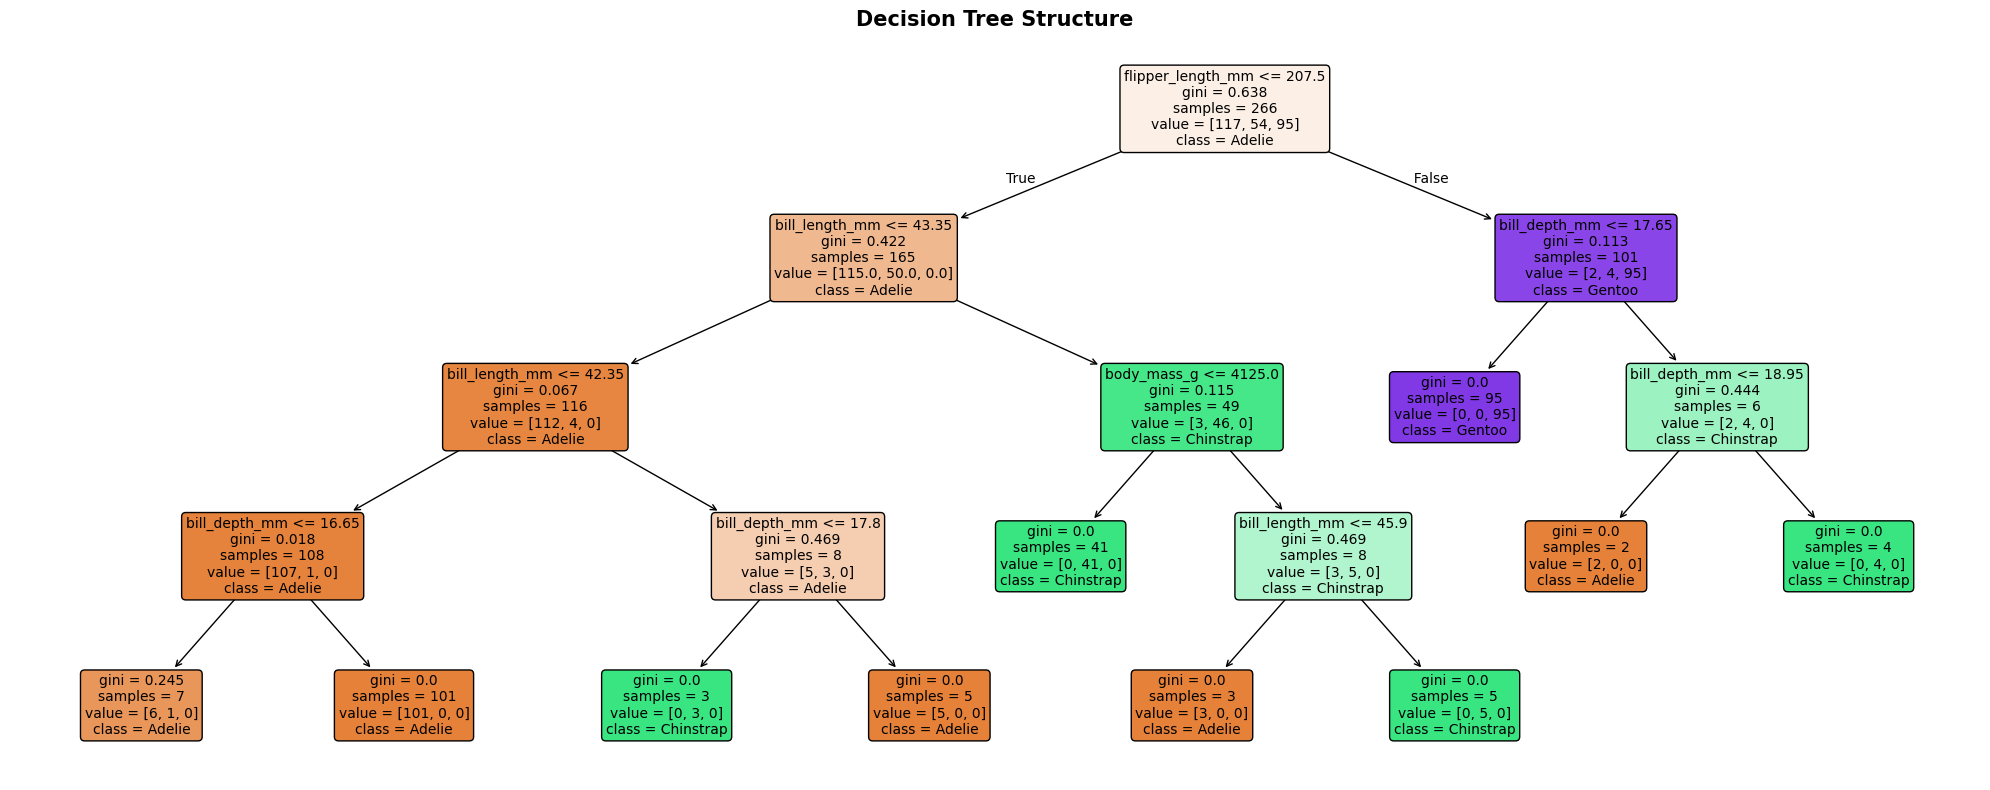

Saved: 6_decision_tree.png


In [10]:
dt_model = results["Decision Tree"]["model"]
plt.figure(figsize=(20, 8))
plot_tree(
    dt_model,
    feature_names=features,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("Decision Tree Structure", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("6_decision_tree.png", dpi=120)
plt.show()
plt.close()
print("Saved: 6_decision_tree.png")

## 9. Feature Importance (Random Forest)

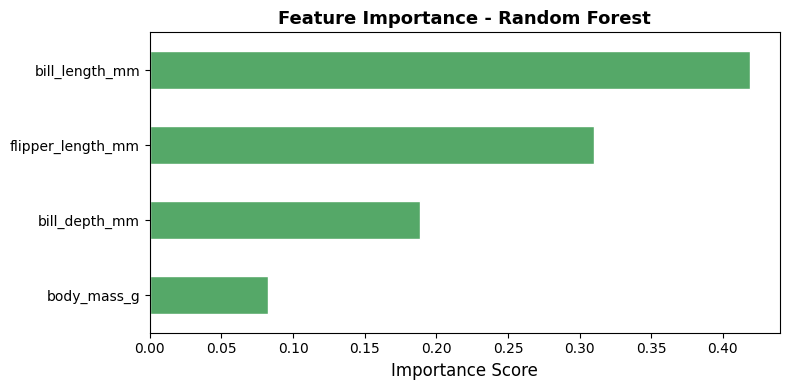

Saved: 7_feature_importance.png


In [11]:
rf_model = results["Random Forest"]["model"]
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
importances.plot(kind="barh", color="#55A868", edgecolor="white")
plt.xlabel("Importance Score", fontsize=12)
plt.title("Feature Importance - Random Forest", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("7_feature_importance.png", dpi=120)
plt.show()
plt.close()
print("Saved: 7_feature_importance.png")

## 10. Predict On A New Penguin

In [12]:
print("\n" + "=" * 50)
print("PREDICTING ON A NEW PENGUIN")
print("=" * 50)

new_penguin = pd.DataFrame({
    "bill_length_mm": [47.5],
    "bill_depth_mm": [14.2],
    "flipper_length_mm": [218.0],
    "body_mass_g": [5200.0],
})

new_scaled = scaler.transform(new_penguin)
prediction = rf_model.predict(new_scaled)
species = le.inverse_transform(prediction)[0]

print(f"Input features : {new_penguin.to_dict('records')[0]}")
print(f"Predicted species : {species}")

print("\n" + "=" * 50)
print("ALL DONE - Check the output PNG files!")
print("=" * 50)


PREDICTING ON A NEW PENGUIN
Input features : {'bill_length_mm': 47.5, 'bill_depth_mm': 14.2, 'flipper_length_mm': 218.0, 'body_mass_g': 5200.0}
Predicted species : Gentoo

ALL DONE - Check the output PNG files!
